# Módulo 3 — EDA: Rossmann Store Sales

EDA previo al entrenamiento de Prophet (y comparativa opcional con XGBoost).
Sigue el mismo criterio de M1/M2: entender el dataset, documentar decisiones de filtrado, y dejar todo listo para `src/sales_predictor/train.py`.

> No requiere GPU. CPU es suficiente.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE_ROOT = '/content/drive/MyDrive/smartretail360'
DATA_DIR   = f'{DRIVE_ROOT}/data/rossmann'

import os
os.makedirs(DATA_DIR, exist_ok=True)

In [ ]:
# --- Monta Drive y define rutas ---
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

DRIVE_ROOT = '/content/drive/MyDrive/smartretail360'
DATA_DIR   = f'{DRIVE_ROOT}/data/rossmann'

import os
os.makedirs(DATA_DIR, exist_ok=True)

# --- Instala kaggle ---
!pip install -q kaggle pandas matplotlib seaborn

from google.colab import files

if not os.path.exists('/root/.kaggle/kaggle.json'):
    print('Subí tu kaggle.json:')
    uploaded = files.upload()
    os.makedirs('/root/.kaggle', exist_ok=True)
    for fn in uploaded:
        os.rename(fn, '/root/.kaggle/kaggle.json')
    os.chmod('/root/.kaggle/kaggle.json', 0o600)

# --- Descarga desde el dataset espejo (no requiere aceptar reglas de competencia) ---
!kaggle datasets download -d pratyushakar/rossmann-store-sales -p {DATA_DIR}

# --- Descomprime ---
import zipfile
zip_path = f'{DATA_DIR}/rossmann-store-sales.zip'
with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(DATA_DIR)
print('Descomprimido en', DATA_DIR)

# --- Verifica archivos ---
print(os.listdir(DATA_DIR))

Mounted at /content/drive
Dataset URL: https://www.kaggle.com/datasets/pratyushakar/rossmann-store-sales
License(s): CC0-1.0
100% 6.90M/6.90M [00:00<00:00, 59.6MB/s]

Descomprimido en /content/drive/MyDrive/smartretail360/data/rossmann
['rossmann-store-sales.zip', 'store.csv', 'test.csv', 'train.csv']


## 1. Carga y merge — train.csv + store.csv

`train.csv` trae solo `Store`, `Date`, `Sales`, `Customers`, `Open`, `Promo`, etc.
`store.csv` trae metadata por tienda: `StoreType`, `Assortment`, `CompetitionDistance`, `Promo2`.
Los unimos por `Store` — Prophet solo usa `ds`/`y`, pero la metadata sirve para decidir *qué* filtrar antes de entrenar.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_train = pd.read_csv(f'{DATA_DIR}/train.csv', parse_dates=['Date'], low_memory=False)
df_store = pd.read_csv(f'{DATA_DIR}/store.csv')

df = df_train.merge(df_store, on='Store', how='left')
print('train.csv:', df_train.shape)
print('store.csv:', df_store.shape)
print('merged   :', df.shape)
df.head()

train.csv: (1017209, 9)
store.csv: (1115, 10)
merged   : (1017209, 18)


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


## 2. Calidad de datos

In [ ]:
print('Tiendas únicas:', df['Store'].nunique())
print('Rango de fechas:', df['Date'].min(), '→', df['Date'].max())
print()
print('Nulos por columna:')
print(df.isnull().sum()[df.isnull().sum() > 0])
print()
print('Duplicados exactos:', df.duplicated().sum())

Tiendas únicas: 1115
Rango de fechas: 2013-01-01 00:00:00 → 2015-07-31 00:00:00

Nulos por columna:
CompetitionDistance            2642
CompetitionOpenSinceMonth    323348
CompetitionOpenSinceYear     323348
Promo2SinceWeek              508031
Promo2SinceYear              508031
PromoInterval                508031
dtype: int64

Duplicados exactos: 0


**Decisión esperada:** `CompetitionDistance`, `CompetitionOpenSince*` y `Promo2Since*` suelen traer nulos (tiendas sin competencia registrada o sin Promo2). Para el modelo de series de tiempo (Prophet) esto no afecta directamente — solo se usa si se agregan features de XGBoost. Documentar el % de nulos aquí antes de decidir imputar o dejar fuera esas columnas.

## 3. Tiendas cerradas (`Open == 0`)

Rossmann incluye filas con `Sales == 0` cuando la tienda estuvo cerrada. Estas filas **distorsionan** la serie de tiempo si no se filtran — Prophet interpretaría el cierre como una caída real de demanda.

In [ ]:
closed_pct = (df['Open'] == 0).mean() * 100
print(f'% de filas con tienda cerrada: {closed_pct:.2f}%')

zero_sales_open = ((df['Open'] == 1) & (df['Sales'] == 0)).sum()
print(f'Filas con Open=1 pero Sales=0 (anomalía): {zero_sales_open}')

# Decisión: filtrar Open == 1 antes de armar la serie por tienda
df_open = df[df['Open'] == 1].copy()
print(f'\nShape tras filtrar tiendas cerradas: {df_open.shape} (era {df.shape})')

% de filas con tienda cerrada: 16.99%
Filas con Open=1 pero Sales=0 (anomalía): 54

Shape tras filtrar tiendas cerradas: (844392, 18) (era (1017209, 18))


## 4. Distribución de ventas (`Sales`)

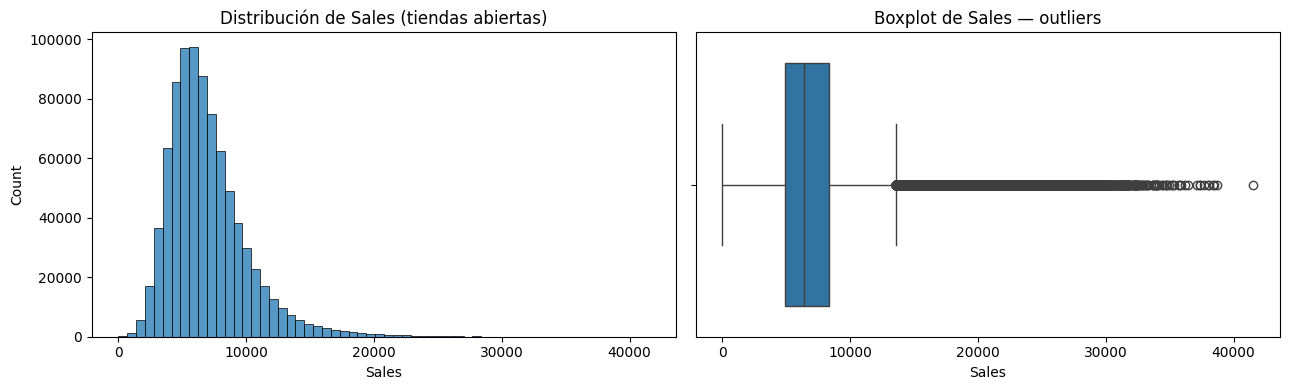

count    844392.000000
mean       6955.514291
std        3104.214680
min           0.000000
25%        4859.000000
50%        6369.000000
75%        8360.000000
max       41551.000000
Name: Sales, dtype: float64

Percentil 99: 17789 — candidato a umbral de outlier si hace falta recortar colas


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(df_open['Sales'], bins=60, ax=axes[0])
axes[0].set_title('Distribución de Sales (tiendas abiertas)')
sns.boxplot(x=df_open['Sales'], ax=axes[1])
axes[1].set_title('Boxplot de Sales — outliers')
plt.tight_layout()
plt.show()

print(df_open['Sales'].describe())

p99 = df_open['Sales'].quantile(0.99)
print(f'\nPercentil 99: {p99:.0f} — candidato a umbral de outlier si hace falta recortar colas')

## 5. Estacionalidad — día de la semana y mes

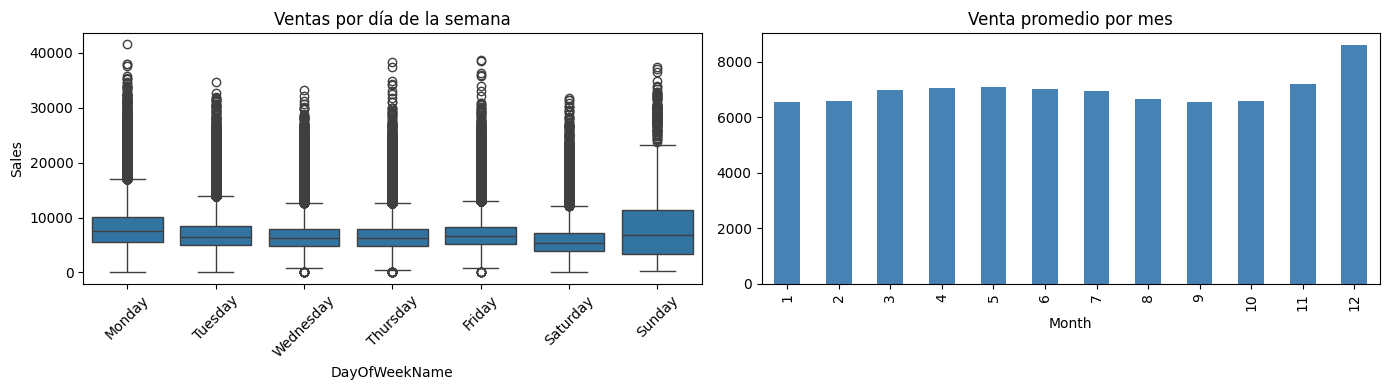

In [ ]:
df_open['DayOfWeekName'] = df_open['Date'].dt.day_name()
df_open['Month'] = df_open['Date'].dt.month

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
sns.boxplot(data=df_open, x='DayOfWeekName', y='Sales', order=order, ax=axes[0])
axes[0].set_title('Ventas por día de la semana')
axes[0].tick_params(axis='x', rotation=45)

monthly = df_open.groupby('Month')['Sales'].mean()
monthly.plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Venta promedio por mes')
plt.tight_layout()
plt.show()

## 6. Efecto de `Promo`

Venta promedio con/sin promoción:
Promo
0    5929.407603
1    8228.281239
Name: Sales, dtype: float64

Diferencia: 2299 (38.8% más con promo)


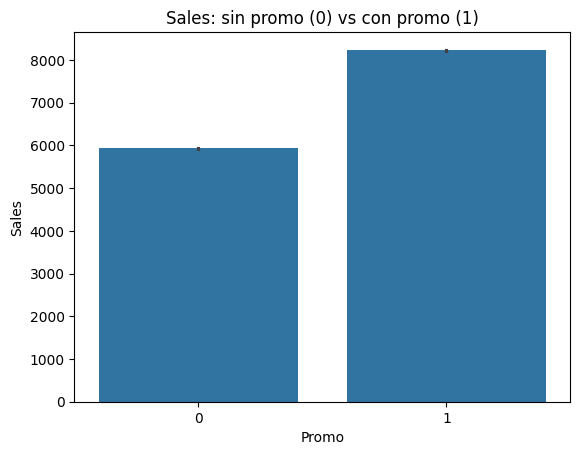

In [ ]:
promo_effect = df_open.groupby('Promo')['Sales'].mean()
print('Venta promedio con/sin promoción:')
print(promo_effect)
print(f'\nDiferencia: {promo_effect[1] - promo_effect[0]:.0f} ({(promo_effect[1]/promo_effect[0] - 1)*100:.1f}% más con promo)')

sns.barplot(data=df_open, x='Promo', y='Sales')
plt.title('Sales: sin promo (0) vs con promo (1)')
plt.show()

## 7. StoreType y Assortment

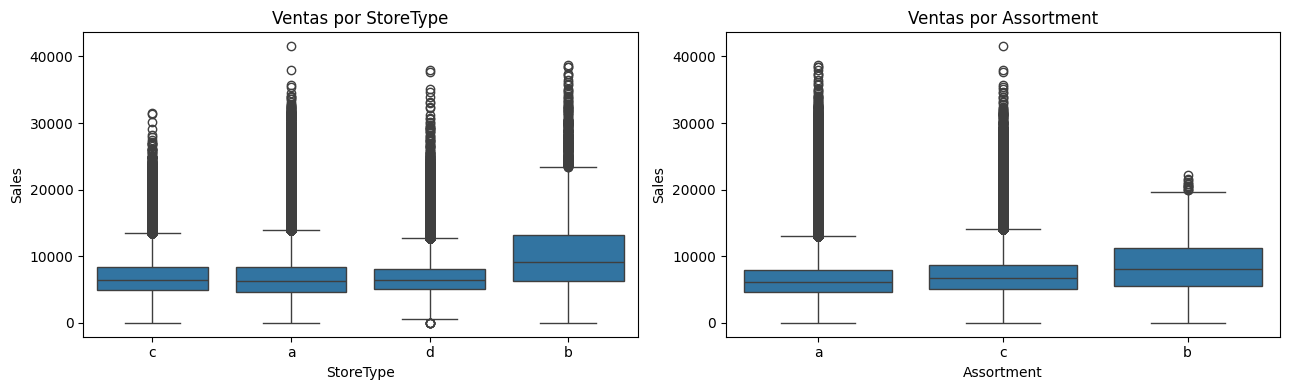

Distribución de tiendas por StoreType:
StoreType
a    602
d    348
c    148
b     17
Name: count, dtype: int64


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.boxplot(data=df_open, x='StoreType', y='Sales', ax=axes[0])
axes[0].set_title('Ventas por StoreType')
sns.boxplot(data=df_open, x='Assortment', y='Sales', ax=axes[1])
axes[1].set_title('Ventas por Assortment')
plt.tight_layout()
plt.show()

print('Distribución de tiendas por StoreType:')
print(df_store['StoreType'].value_counts())

## 8. Serie de tiempo — ejemplo de una tienda

Vista previa de cómo se ve la serie que Prophet va a recibir (`prepare_prophet_df` en `src/sales_predictor/features.py`).

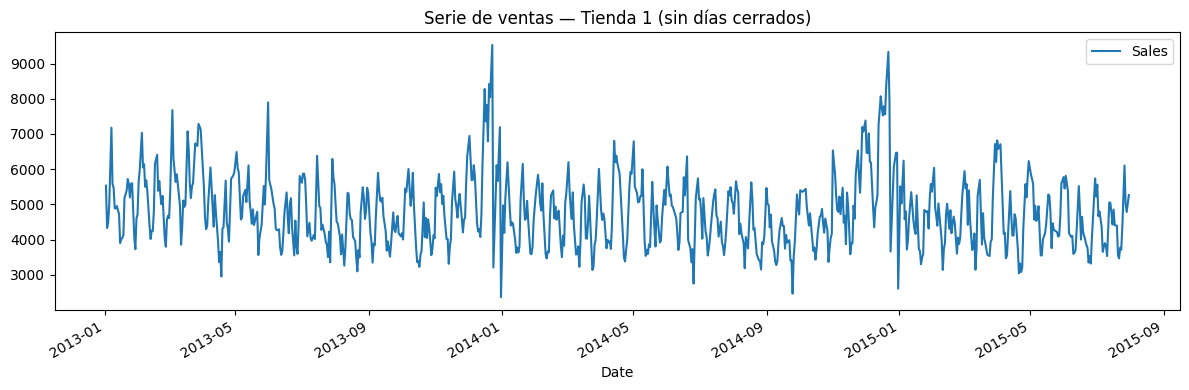

Días con datos: 781
Huecos en la serie (días cerrados excluidos): 160


In [ ]:
STORE_ID = 1
store_series = df_open[df_open['Store'] == STORE_ID][['Date', 'Sales']].sort_values('Date')

store_series.plot(x='Date', y='Sales', figsize=(12, 4), title=f'Serie de ventas — Tienda {STORE_ID} (sin días cerrados)')
plt.tight_layout()
plt.show()

print(f'Días con datos: {len(store_series)}')
print(f'Huecos en la serie (días cerrados excluidos): {(store_series["Date"].max() - store_series["Date"].min()).days + 1 - len(store_series)}')

## 9. Conclusiones y decisiones para el entrenamiento

- **Filtrado obligatorio:** `Open == 1` antes de armar la serie por tienda — ya está resuelto en `src/sales_predictor/features.py::prepare_prophet_df`, pero falta agregar el filtro `Open==1` ahí explícitamente (revisar).
- **Outliers:** evaluar recorte al percentil 99 si el MAE de Prophet sale muy afectado por picos (ej. temporada navideña).
- **Promo como regressor:** el efecto es significativo — candidato a agregar como `add_regressor('Promo')` en `prophet_model.py`, además del `sentiment` que ya está planeado para M2→M3.
- **StoreType/Assortment:** no se usan directamente en Prophet (es univariado por tienda), pero sí en el modelo XGBoost de comparación (`xgboost_model.py`) si se decide incluir features de tienda.
- **Próximo paso:** correr `train.py::train_prophet()` con `store_id=1` como piloto, comparar MAE/RMSE/MAPE, y luego decidir si se entrena por tienda o un modelo global.